## preparing TA snRNA dataset using Scanpy

In [1]:
import scanpy as sc
import anndata as ad
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# load anndata objects
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_celloracle_compatible.h5ad')
adata

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

#### Filter more cells

In [3]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[:, (~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb'])] # Filter mitochondrial, ribosomal, haemoglobin genes
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Number of cells after filtering of low quality cells: 81614


In [6]:
male_adata_subset = adata[adata.obs['sex'] == 'M']
female_adata_subset = adata[adata.obs['sex'] == 'F']

In [7]:
# save the sex specific adata objects
male_adata_subset.write_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/male_adata_jan_26.h5ad')
female_adata_subset.write_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/female_adata_jan_26.h5ad')

In [ ]:
# save in dense format for Seurat
# Function to convert to dense format
def convert_to_dense(adata):
    # Convert main matrix to dense
    if hasattr(adata.X, 'toarray'):
        adata.X = adata.X.toarray()
    
    # Convert all layers to dense if they exist
    if adata.layers:
        for layer_name in adata.layers.keys():
            if hasattr(adata.layers[layer_name], 'toarray'):
                adata.layers[layer_name] = adata.layers[layer_name].toarray()
    
    return adata

# Convert to dense
female_adata = convert_to_dense(female_adata_subset)
male_adata = convert_to_dense(male_adata_subset)

# Save in dense format
female_adata.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/female_jan_26_dense.h5ad", 
                        compression='gzip')
male_adata.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/male_jan_26_dense.h5ad", 
                      compression='gzip')

print("Dense h5ad files saved successfully!")

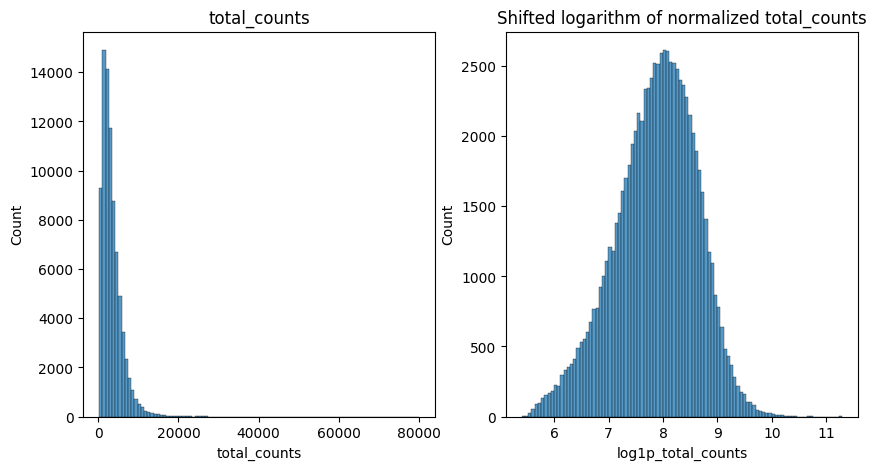

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("total_counts")
sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm of normalized total_counts")
plt.show()

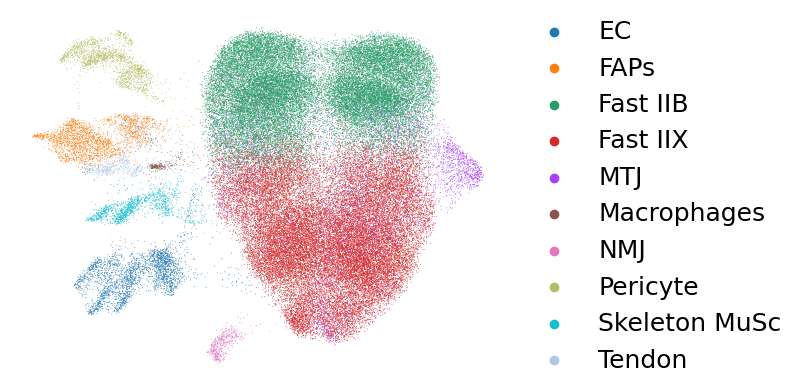

In [7]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(adata, color=['C_scANVI'], frameon=False, legend_fontsize=18,
           legend_fontweight='bold', legend_fontoutline=2, title='')

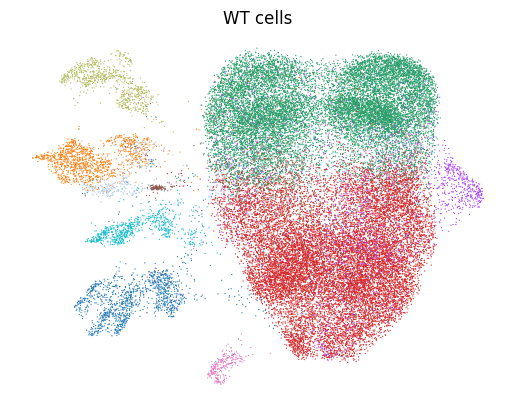

In [10]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(wt_adata_subset, color=['C_scANVI'], frameon=False, title='WT cells', show=True, legend_loc=None)

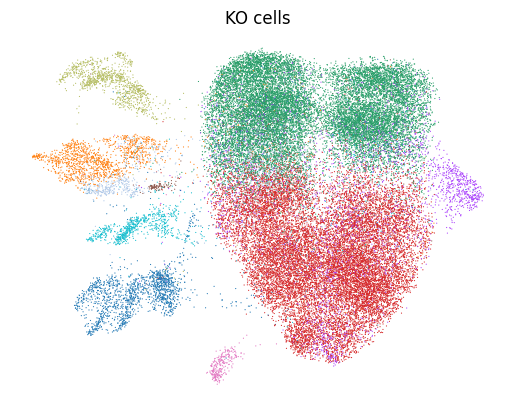

In [11]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(ko_adata_subset, color=['C_scANVI'], frameon=False, title='KO cells', show=True, legend_loc=None)

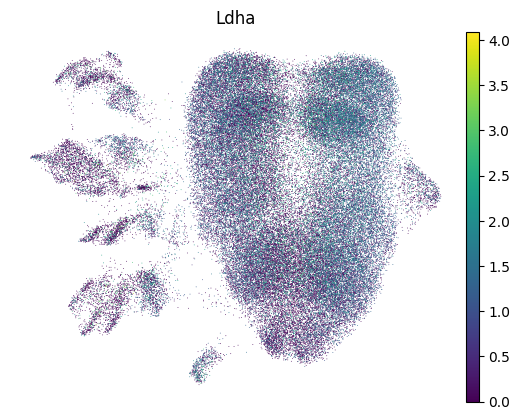

In [19]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(adata, color=['Ldha'], frameon=False, legend_fontsize=18,
           legend_fontweight='bold', legend_fontoutline=2)

### Gene expression plots

In [ ]:
# get DEGs to plot heatmaps
